# Loan Default Risk — Modelling and Evaluation

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

from src.loader import load_and_merge
from src.features import engineer_model_features
from src.model import (
    get_models, get_param_grids, tune_model, save_model, predict_proba,
    build_pipeline, run_smote_ablation, build_stacking_ensemble, calibrate_model
)
from src.evaluate import (
    evaluate_model, find_optimal_threshold,
    plot_confusion_matrix, plot_roc_curves, plot_shap_summary
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

## 1. Load, Merge, and Engineer Features

In [2]:
train_df = load_and_merge(split="train")
print(f"Merged training data shape: {train_df.shape}")
train_df.head()

Merged training data shape: (4376, 37)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_avg_days_late,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred,recent_1_days_late,recent_1_paid_late,recent_3_late_rate,recent_3_avg_days_late,recent_2_late_rate,recent_2_avg_days_late,lateness_trend
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0000,34500.0000,30,NaN,Good,1972-01-15 00:00:00.000000,Other,3.4320,6.4331,Diamond Bank,NaN,Permanent,Post-Graduate,11.0000,18181.8182,30000.0000,22081.8182,30.0000,-0.9091,39.0000,0.2727,3.0000,0.2291,29.4545,0.0000,-6.0000,0.0000,0.0000,-6.0000,0.0000,-7.0000,0.9273
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0000,17250.0000,30,NaN,Good,1985-08-23 00:00:00.000000,Savings,3.8853,7.3207,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0000,22250.0000,15,NaN,Good,1984-09-18 00:00:00.000000,Other,11.1393,10.2920,EcoBank,NaN,Permanent,NaN,6.0000,10000.0000,10000.0000,11750.0000,17.5000,0.8333,30.0000,0.1667,1.0000,0.1750,18.1667,0.0000,0.0000,0.0000,0.3333,10.0000,0.0000,0.0000,3.1143
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0000,11500.0000,15,NaN,Good,1977-10-10 00:00:00.000000,Savings,3.9858,7.4917,First Bank,NaN,Permanent,NaN,2.0000,10000.0000,10000.0000,12250.0000,22.5000,7.5000,11.0000,1.0000,2.0000,0.2250,31.5000,0.0000,11.0000,1.0000,1.0000,7.5000,1.0000,7.5000,7.0000
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0000,44000.0000,30,NaN,Good,1986-09-07 00:00:00.000000,Other,7.4579,9.0766,GT Bank,NaN,Permanent,Primary,8.0000,18750.0000,30000.0000,23550.0000,37.5000,-3.1250,-1.0000,0.0000,0.0000,0.2587,27.0000,0.0000,-1.0000,0.0000,0.0000,-1.3333,0.0000,-1.5000,0.9881


In [3]:
X, y = engineer_model_features(train_df, is_train=True)
print(f"Feature matrix shape: {X.shape}")
print(f"Class balance: {y.mean()*100:.1f}% Good, {(1-y.mean())*100:.1f}% Bad")

Feature matrix shape: (4376, 54)
Class balance: 78.2% Good, 21.8% Bad


## 2. Time-Based Train / Validation Split

In [4]:
# Time-based split — train on oldest 80%, validate on most recent 20%
train_df_sorted = train_df.copy()
train_df_sorted["approveddate"] = pd.to_datetime(train_df_sorted["approveddate"])
train_df_sorted = train_df_sorted.sort_values("approveddate").reset_index(drop=True)

split_idx = int(len(train_df_sorted) * 0.8)
train_split = train_df_sorted.iloc[:split_idx]
val_split   = train_df_sorted.iloc[split_idx:]

X_train, y_train = engineer_model_features(train_split, is_train=True)
X_val, y_val     = engineer_model_features(val_split,   is_train=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print(f"Training set:   {X_train.shape} | {train_split['approveddate'].min().date()} to {train_split['approveddate'].max().date()}")
print(f"Validation set: {X_val.shape}   | {val_split['approveddate'].min().date()} to {val_split['approveddate'].max().date()}")
print(f"Training Bad rate:   {(1-y_train.mean())*100:.1f}%")
print(f"Validation Bad rate: {(1-y_val.mean())*100:.1f}%")

Training set:   (3500, 54) | 2017-07-01 to 2017-07-25
Validation set: (876, 54)   | 2017-07-25 to 2017-07-30
Training Bad rate:   21.6%
Validation Bad rate: 22.4%


## 3. Baseline Model — Logistic Regression

In [5]:
baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    scale=True
)
baseline.fit(X_train, y_train)
baseline_proba = predict_proba(baseline, X_val)
baseline_metrics = evaluate_model(y_val, baseline_proba)
print("Baseline Logistic Regression:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline Logistic Regression:
  roc_auc: 0.7051
  f1_macro: 0.5468
  f1_weighted: 0.6096
  precision_bad: 0.3087
  recall_bad: 0.7245
  f1_bad: 0.4329
  precision_good: 0.8702
  recall_good: 0.5324
  f1_good: 0.6606
  accuracy: 0.5753
  threshold: 0.5000


## 4. SMOTE Ablation

In [6]:
print("Running SMOTE ablation...")
ablation_results = run_smote_ablation(X_train, y_train, X_val, y_val)
ablation_results

Running SMOTE ablation...
  Running strategy: none
  Running strategy: class_weight
  Running strategy: smote
  Running strategy: smote_tomek


,model,strategy,roc_auc,f1_bad,recall_bad
0,logistic_regression,none,0.7052,0.4543,0.4184
1,logistic_regression,class_weight,0.7101,0.4485,0.6327
2,logistic_regression,smote_tomek,0.7118,0.4475,0.6735
3,logistic_regression,smote,0.7119,0.4452,0.6735
4,random_forest,smote,0.7174,0.4989,0.5561
5,random_forest,smote_tomek,0.7163,0.4966,0.5510
6,random_forest,class_weight,0.7167,0.4884,0.5357
7,random_forest,none,0.7122,0.3737,0.2755
8,xgboost,class_weight,0.6962,0.3675,0.3112
9,xgboost,smote,0.6850,0.3436,0.2551


## 5. Model Comparison (Pre-tuning)

In [7]:
models = get_models()
results_pretune = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    proba = predict_proba(pipeline, X_val)
    metrics = evaluate_model(y_val, proba)
    results_pretune[name] = metrics
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f}")

summary_pretune = pd.DataFrame(results_pretune).T
summary_pretune[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7051 | F1-macro=0.5468
random_forest: ROC-AUC=0.6915 | F1-macro=0.6090
xgboost: ROC-AUC=0.6812 | F1-macro=0.5794


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7051,0.5468,0.4329,0.7245,0.3087
random_forest,0.6915,0.6090,0.3541,0.2755,0.4954
xgboost,0.6812,0.5794,0.2909,0.2041,0.5063


## 6. Hyperparameter Tuning — RandomizedSearchCV

**This cell takes several minutes to run.**

In [8]:
param_grids = get_param_grids()
tuned_models = {}

for name, pipeline in get_models().items():
    search = tune_model(
        name=name,
        pipeline=pipeline,
        param_grid=param_grids[name],
        X_train=X_train,
        y_train=y_train,
        n_iter=30,
        cv=5,
        use_time_cv=False
    )
    tuned_models[name] = search.best_estimator_

TypeError: tune_model() got an unexpected keyword argument 'use_time_cv'

In [ ]:
results_tuned = {}
roc_data = {}

for name, model in tuned_models.items():
    proba = predict_proba(model, X_val)
    metrics = evaluate_model(y_val, proba)
    results_tuned[name] = metrics
    roc_data[name] = {"y_true": y_val, "y_pred_proba": proba}
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

summary_tuned = pd.DataFrame(results_tuned).T
summary_tuned[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7100 | F1-macro=0.5697 | Recall-bad=0.6888
random_forest: ROC-AUC=0.7157 | F1-macro=0.6620 | Recall-bad=0.5408
xgboost: ROC-AUC=0.6606 | F1-macro=0.6172 | Recall-bad=0.3214


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7100,0.5697,0.4405,0.6888,0.3237
random_forest,0.7157,0.6620,0.4907,0.5408,0.4492
xgboost,0.6606,0.6172,0.3795,0.3214,0.4632


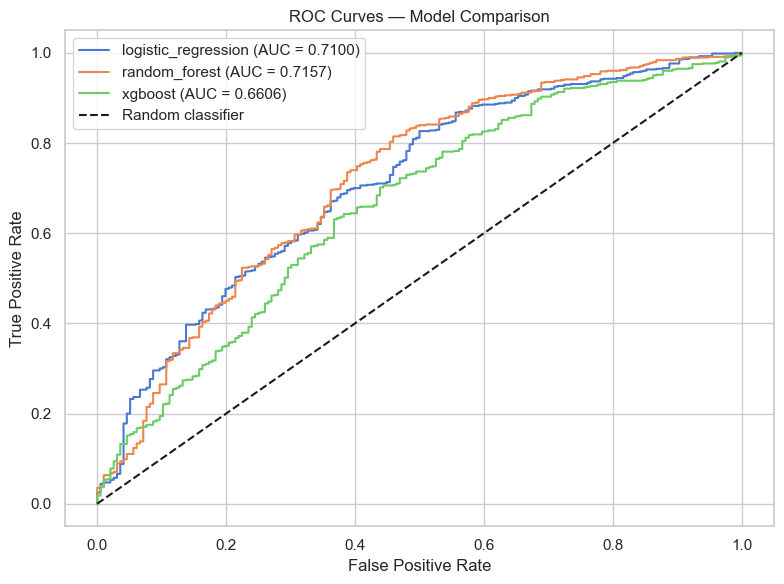

In [ ]:
plot_roc_curves(roc_data)

## 7. Threshold Optimisation (Best Individual Model)

In [ ]:
best_model_name = max(results_tuned, key=lambda k: results_tuned[k]["roc_auc"])
best_model = tuned_models[best_model_name]
best_proba = predict_proba(best_model, X_val)

print(f"Best model: {best_model_name}")
optimal_threshold = find_optimal_threshold(y_val, best_proba)

metrics_default = evaluate_model(y_val, best_proba, threshold=0.5)
metrics_optimal = evaluate_model(y_val, best_proba, threshold=optimal_threshold)

comparison = pd.DataFrame({
    "threshold=0.5": metrics_default,
    f"threshold={optimal_threshold:.3f}": metrics_optimal
}).T
comparison[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

Best model: random_forest
Optimal threshold: 0.4700 (F1 Bad class: 0.4915)


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
threshold=0.5,0.7157,0.6620,0.4907,0.5408,0.4492
threshold=0.470,0.7157,0.6678,0.4915,0.5153,0.4698


## 8. Stacking Ensemble — Configuration Comparison

In [ ]:
# Pre-impute before stacking to prevent NaN errors in meta-learner
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=X_val.columns)

lr_base  = tuned_models["logistic_regression"]
rf_base  = tuned_models["random_forest"]
xgb_base = tuned_models["xgboost"]

print("Calibrating RF...")
rf_cal = calibrate_model(rf_base, X_train_imp, y_train, method="sigmoid")

stack_configs = {
    "LR+RF (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+XGB (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("xgb", xgb_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF (C=0.01)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=0.01, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF (C=1.0)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF passthrough (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, passthrough=True, n_jobs=-1
    ),
}

stack_results = {}
for config_name, stack in stack_configs.items():
    print(f"  Fitting: {config_name}")
    stack.fit(X_train_imp, y_train)
    proba = predict_proba(stack, X_val_imp)
    opt_thresh = find_optimal_threshold(y_val, proba)
    metrics = evaluate_model(y_val, proba, threshold=opt_thresh)
    stack_results[config_name] = {
        "roc_auc": metrics["roc_auc"],
        "f1_bad":  metrics["f1_bad"],
        "recall_bad": metrics["recall_bad"],
        "precision_bad": metrics["precision_bad"],
        "threshold": opt_thresh,
        "model": stack
    }
    print(f"    ROC-AUC={metrics['roc_auc']:.4f} | F1 Bad={metrics['f1_bad']:.4f} | Recall Bad={metrics['recall_bad']:.4f}")

stack_summary = pd.DataFrame({k: {m: v for m, v in v.items() if m != "model"}
                               for k, v in stack_results.items()}).T
stack_summary[["roc_auc", "f1_bad", "recall_bad", "precision_bad", "threshold"]]

Calibrating RF...
  Fitting: LR+RF (C=0.1)
Optimal threshold: 0.4800 (F1 Bad class: 0.4744)
    ROC-AUC=0.7220 | F1 Bad=0.4744 | Recall Bad=0.5663
  Fitting: LR+RF+XGB (C=0.1)
Optimal threshold: 0.4700 (F1 Bad class: 0.4764)
    ROC-AUC=0.7244 | F1 Bad=0.4764 | Recall Bad=0.5663
  Fitting: LR+RF (C=0.01)
Optimal threshold: 0.4900 (F1 Bad class: 0.4716)
    ROC-AUC=0.7215 | F1 Bad=0.4716 | Recall Bad=0.5510
  Fitting: LR+RF (C=1.0)
Optimal threshold: 0.4400 (F1 Bad class: 0.4753)
    ROC-AUC=0.7230 | F1 Bad=0.4753 | Recall Bad=0.5153
  Fitting: LR+RF passthrough (C=0.1)
Optimal threshold: 0.4300 (F1 Bad class: 0.4689)
    ROC-AUC=0.7069 | F1 Bad=0.4689 | Recall Bad=0.5000


,roc_auc,f1_bad,recall_bad,precision_bad,threshold
LR+RF (C=0.1),0.7220,0.4744,0.5663,0.4081,0.4800
LR+RF+XGB (C=0.1),0.7244,0.4764,0.5663,0.4111,0.4700
LR+RF (C=0.01),0.7215,0.4716,0.5510,0.4122,0.4900
LR+RF (C=1.0),0.7230,0.4753,0.5153,0.4410,0.4400
LR+RF passthrough (C=0.1),0.7069,0.4689,0.5000,0.4414,0.4300


## 9. Threshold Sweep on Best Stack

Sweep lower thresholds specifically to maximise recall on the Bad class.

In [ ]:
# Pick best stack config by ROC-AUC
best_stack_name = max(stack_results, key=lambda k: stack_results[k]["roc_auc"])
best_stack = stack_results[best_stack_name]["model"]
best_stack_proba = predict_proba(best_stack, X_val_imp)

print(f"Best stack config: {best_stack_name}")
print("\nThreshold sweep (optimising recall Bad):")

sweep_results = []
for t in np.arange(0.30, 0.55, 0.01):
    m = evaluate_model(y_val, best_stack_proba, threshold=round(t, 2))
    sweep_results.append({
        "threshold": round(t, 2),
        "recall_bad": m["recall_bad"],
        "precision_bad": m["precision_bad"],
        "f1_bad": m["f1_bad"],
        "roc_auc": m["roc_auc"]
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

Best stack config: LR+RF+XGB (C=0.1)

Threshold sweep (optimising recall Bad):
 threshold  recall_bad  precision_bad  f1_bad  roc_auc
    0.3000      0.3520         0.5267  0.4220   0.7244
    0.3100      0.3571         0.5303  0.4268   0.7244
    0.3200      0.3622         0.5259  0.4290   0.7244
    0.3300      0.3827         0.5208  0.4412   0.7244
    0.3400      0.3929         0.5133  0.4451   0.7244
    0.3500      0.4031         0.5097  0.4501   0.7244
    0.3600      0.4082         0.4969  0.4482   0.7244
    0.3700      0.4235         0.4911  0.4548   0.7244
    0.3800      0.4286         0.4828  0.4541   0.7244
    0.3900      0.4490         0.4757  0.4619   0.7244
    0.4000      0.4592         0.4639  0.4615   0.7244
    0.4100      0.4643         0.4483  0.4561   0.7244
    0.4200      0.4745         0.4408  0.4570   0.7244
    0.4300      0.4847         0.4318  0.4567   0.7244
    0.4400      0.4949         0.4236  0.4565   0.7244
    0.4500      0.5153         0.4262  0.

## 10. Save Best Model

In [ ]:
save_model(best_stack, name="best_stack")
print(f"Saved best stack: {best_stack_name}")

Model saved to C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\loan-default-risk\outputs\models\best_stack.joblib
Saved best stack: LR+RF+XGB (C=0.1)


## 11. SHAP Explainability

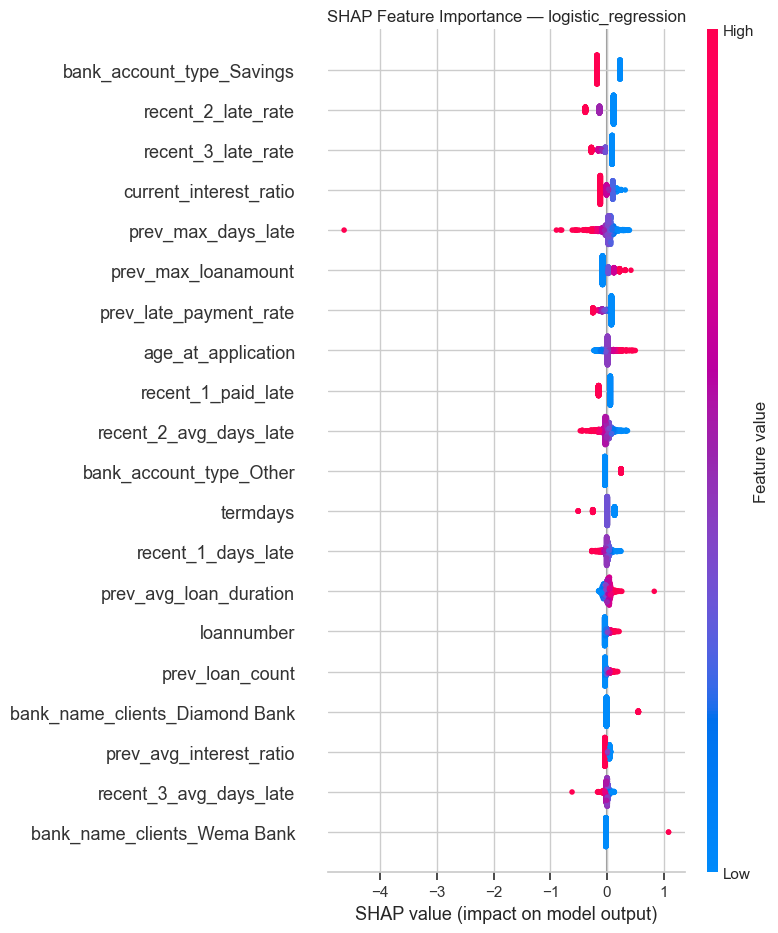

In [ ]:
plot_shap_summary(tuned_models["logistic_regression"], X_val, model_name="logistic_regression")

## 12. Summary of Results Across All Iterations

| Version | Val ROC-AUC | Recall Bad | F1 Bad | LB Score |
|---|---|---|---|---|
| Baseline | 0.6885 | 0.6545 | 0.4325 | 0.4007 |
| Iteration 2 (recency features) | 0.6929 | 0.6073 | 0.4386 | 0.3448 |
| Iteration 3 (pruned features) | 0.6861 | 0.6545 | 0.4371 | 0.3703 |
| Iteration 4 (stacking) | 0.6865 | 0.5707 | 0.4360 | 0.3448 |
| Iteration 5 (time-based val) | 0.7214 | 0.6122 | 0.4727 | 0.2503 |
| Iteration 6 (time CV tuning) | 0.7163 | 0.5510 | 0.4909 | 0.2683 |
| Iteration 7 (stack tuned) | 0.7244 | 0.5663 | 0.4764 | 0.2731 |

## 13. Generate Zindi Submission

**NOTE:** Always pass `train_columns` when processing test data.

In [ ]:
# Choose threshold from sweep — pick the one that maximises recall_bad
# Update submit_threshold below based on sweep results above
submit_threshold = 0.39  # update this after reviewing the sweep table

test_df = load_and_merge(split="test")
X_test, _ = engineer_model_features(test_df, is_train=False, train_columns=X_train.columns.tolist())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

test_proba = predict_proba(best_stack, X_test_imp)
test_pred  = (test_proba >= submit_threshold).astype(int)

print(f"Threshold used: {submit_threshold}")
print(f"Predictions: {pd.Series(test_pred).value_counts().to_dict()}")

submission = pd.DataFrame({
    "customerid": test_df["customerid"].values,
    "Good_Bad_flag": test_pred
})
submission_path = f"../outputs/submissions/submission_thresh{submit_threshold}.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved to {submission_path}")
submission.head()

Threshold used: 0.39
Predictions: {1: 1142, 0: 308}
Saved to ../outputs/submissions/submission_0.39_thresh0.39.csv


,customerid,Good_Bad_flag
0,8a858899538ddb8e015390510b321f08,1
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,0
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1
